In [78]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv("06-study_hours_grades.csv")

In [80]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [82]:
X = torch.tensor(df["study_hours"].values, dtype = torch.float32).unsqueeze(1)
y = torch.tensor(df["grade"].values, dtype = torch.float32).unsqueeze(1)

In [83]:
X

tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])

In [84]:
X.shape

torch.Size([50, 1])

In [85]:
X.ndim

2

In [86]:
train_split_rate = int(len(X) * 0.8)
X_train, y_train = X[:train_split_rate], y[:train_split_rate]
X_test, y_test = X[train_split_rate:], y[train_split_rate:]

In [87]:
len(X_train), len(X_test)

(40, 10)

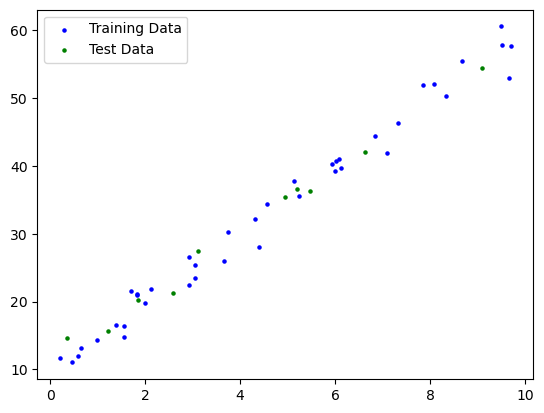

In [88]:
plt.scatter(X_train, y_train, c = "b", label = "Training Data", s = 5)
plt.scatter(X_test, y_test, c = "g", label = "Test Data", s = 5)
plt.legend()
plt.show()

In [89]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
        

In [90]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [91]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [92]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [93]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.001)

In [96]:
epochs = 120

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if (epoch % 5 == 0):
            print(f"Epoch: {epoch}, Train Loss: {loss:.2f}, Test Loss: {test_loss:.2f}")

Epoch: 0, Train Loss: 20.75, Test Loss: 25.66
Epoch: 5, Train Loss: 20.65, Test Loss: 25.54
Epoch: 10, Train Loss: 20.56, Test Loss: 25.42
Epoch: 15, Train Loss: 20.46, Test Loss: 25.30
Epoch: 20, Train Loss: 20.36, Test Loss: 25.19
Epoch: 25, Train Loss: 20.27, Test Loss: 25.07
Epoch: 30, Train Loss: 20.18, Test Loss: 24.96
Epoch: 35, Train Loss: 20.08, Test Loss: 24.84
Epoch: 40, Train Loss: 19.99, Test Loss: 24.73
Epoch: 45, Train Loss: 19.90, Test Loss: 24.62
Epoch: 50, Train Loss: 19.80, Test Loss: 24.51
Epoch: 55, Train Loss: 19.71, Test Loss: 24.40
Epoch: 60, Train Loss: 19.62, Test Loss: 24.29
Epoch: 65, Train Loss: 19.53, Test Loss: 24.18
Epoch: 70, Train Loss: 19.44, Test Loss: 24.07
Epoch: 75, Train Loss: 19.35, Test Loss: 23.96
Epoch: 80, Train Loss: 19.26, Test Loss: 23.86
Epoch: 85, Train Loss: 19.18, Test Loss: 23.75
Epoch: 90, Train Loss: 19.09, Test Loss: 23.65
Epoch: 95, Train Loss: 19.00, Test Loss: 23.54
Epoch: 100, Train Loss: 18.91, Test Loss: 23.43
Epoch: 105, Tr

In [97]:
print(model.state_dict())

OrderedDict({'linear_layer.weight': tensor([[6.1318]]), 'linear_layer.bias': tensor([2.7445])})


In [99]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

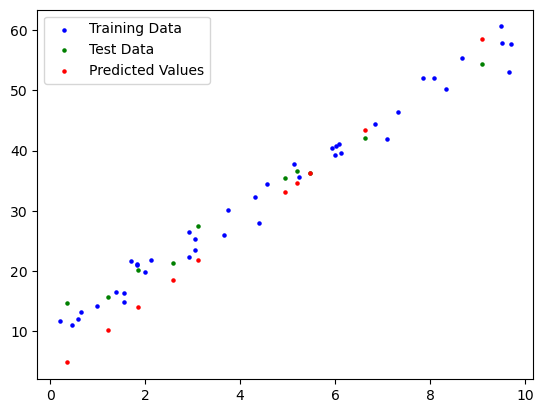

In [100]:
plt.scatter(X_train, y_train, c = "b", label = "Training Data", s = 5)
plt.scatter(X_test, y_test, c = "g", label = "Test Data", s = 5)
plt.scatter(X_test, y_preds, c = "r", label = "Predicted Values", s = 5)
plt.legend()
plt.show()